In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
# === CONFIG ===
IMAGE_PATH = "/Users/mariamhusain/Desktop/Eyedentify-AI/data/filtered/infected_eye/5.jpg"
MODEL_WEIGHTS = "/Users/mariamhusain/Desktop/resnet18_weights.pth"
LABELS = {0: "Healthy", 1: "Infected"}

In [3]:
# === Load model and weights ===
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location='cpu'))
model.eval()

/Users/mariamhusain/Desktop/eyedentify-ai/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mariamhusain/Desktop/eyedentify-ai/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# === Preprocess image ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

img_pil = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(img_pil.resize((224, 224))) / 255.0
input_tensor = transform(img_pil).unsqueeze(0)

In [5]:
# === Grad-CAM++ Setup ===
target_layer = model.layer4[-1]
cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])

In [6]:
# === Model Prediction ===
with torch.no_grad():
    output = model(input_tensor)
    prob = torch.sigmoid(output).item()
    pred_label = 1 if prob > 0.5 else 0

In [7]:
# === Generate CAM mask ===
target = [BinaryClassifierOutputTarget(pred_label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]

In [8]:
# === Overlay on original image ===
cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

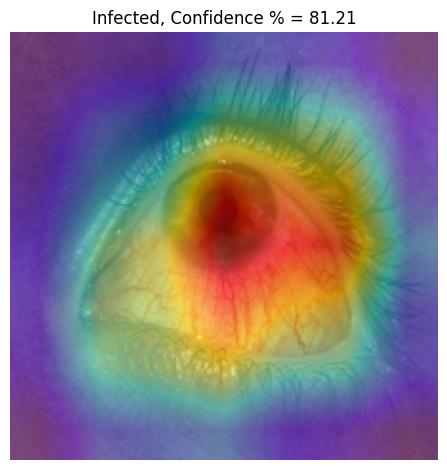

In [9]:
# === Display ===
plt.imshow(cam_image)
plt.axis('off')
plt.title(f"{LABELS[pred_label]}, Confidence % = {prob * 100:.2f}")
plt.tight_layout()
plt.show()